In [1]:
# Generate a complete PCA example for swimmers.
# This code will produce:
# - a synthetic data table (80 swimmers, 6 variables)
# - standardization, PCA (2 components)
# - loadings table (variable <-> component correlations)
# - scatter plot of individuals on the PC1 x PC2 plane
# - correlation circle (variables projected on component space)

# Uses matplotlib (not seaborn)

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from IPython.display import display
import sys
from pathlib import Path

scripts_path = Path("scripts")
sys.path.append(str(scripts_path))

## 1. Creation des donnees

In [2]:
# create of a dataset synthetic for 80 swimmers
n = 200

# Variable principale
temps_50m = np.random.normal(loc=28, scale=1.2, size=n)

# 100m ≈ 2 * 50m + 6-8s
temps_100m = temps_50m * 2 + np.random.normal(loc=7, scale=0.8, size=n)

# Speed très fortement corrélée avec le 50m
# (plus le temps est petit, plus la vitesse est grande)
vitesse = 1.8 - 0.05 * (temps_50m - 28) + np.random.normal(0, 0.03, n)

# Heart rate corrélé avec la difficulté / durée du 100m
freq_card = 150 + 0.8 * (temps_100m - 62) + np.random.normal(0, 3, n)

# Fatigue augmente quand le temps 100m augmente
fatigue = 3.5 + 0.1 * (temps_100m - 62) + np.random.normal(0, 0.4, n)

# Strokes diminue quand le nageur est plus rapide
nb_bras = 14 - 0.2 * (temps_100m - 62) + np.random.normal(0, 0.8, n)

data = {
    "temps_50m": temps_50m,
    "temps_100m": temps_100m,
    "freq_card": freq_card,
    "vitesse": vitesse,
    "fatigue": fatigue,
    "nb_bras": nb_bras
}

data = pd.DataFrame(data)
data = data.round(2)
data.head()


,temps_50m,temps_100m,freq_card,vitesse,fatigue,nb_bras
0,27.52,62.61,151.96,1.80,4.06,13.27
1,28.49,64.35,153.61,1.74,3.04,13.95
2,25.97,59.06,150.13,1.91,3.68,15.33
3,28.90,65.34,150.30,1.74,3.96,11.59
4,27.95,63.02,142.77,1.86,3.38,13.84


## 2. Etudes des correlations entre les variables

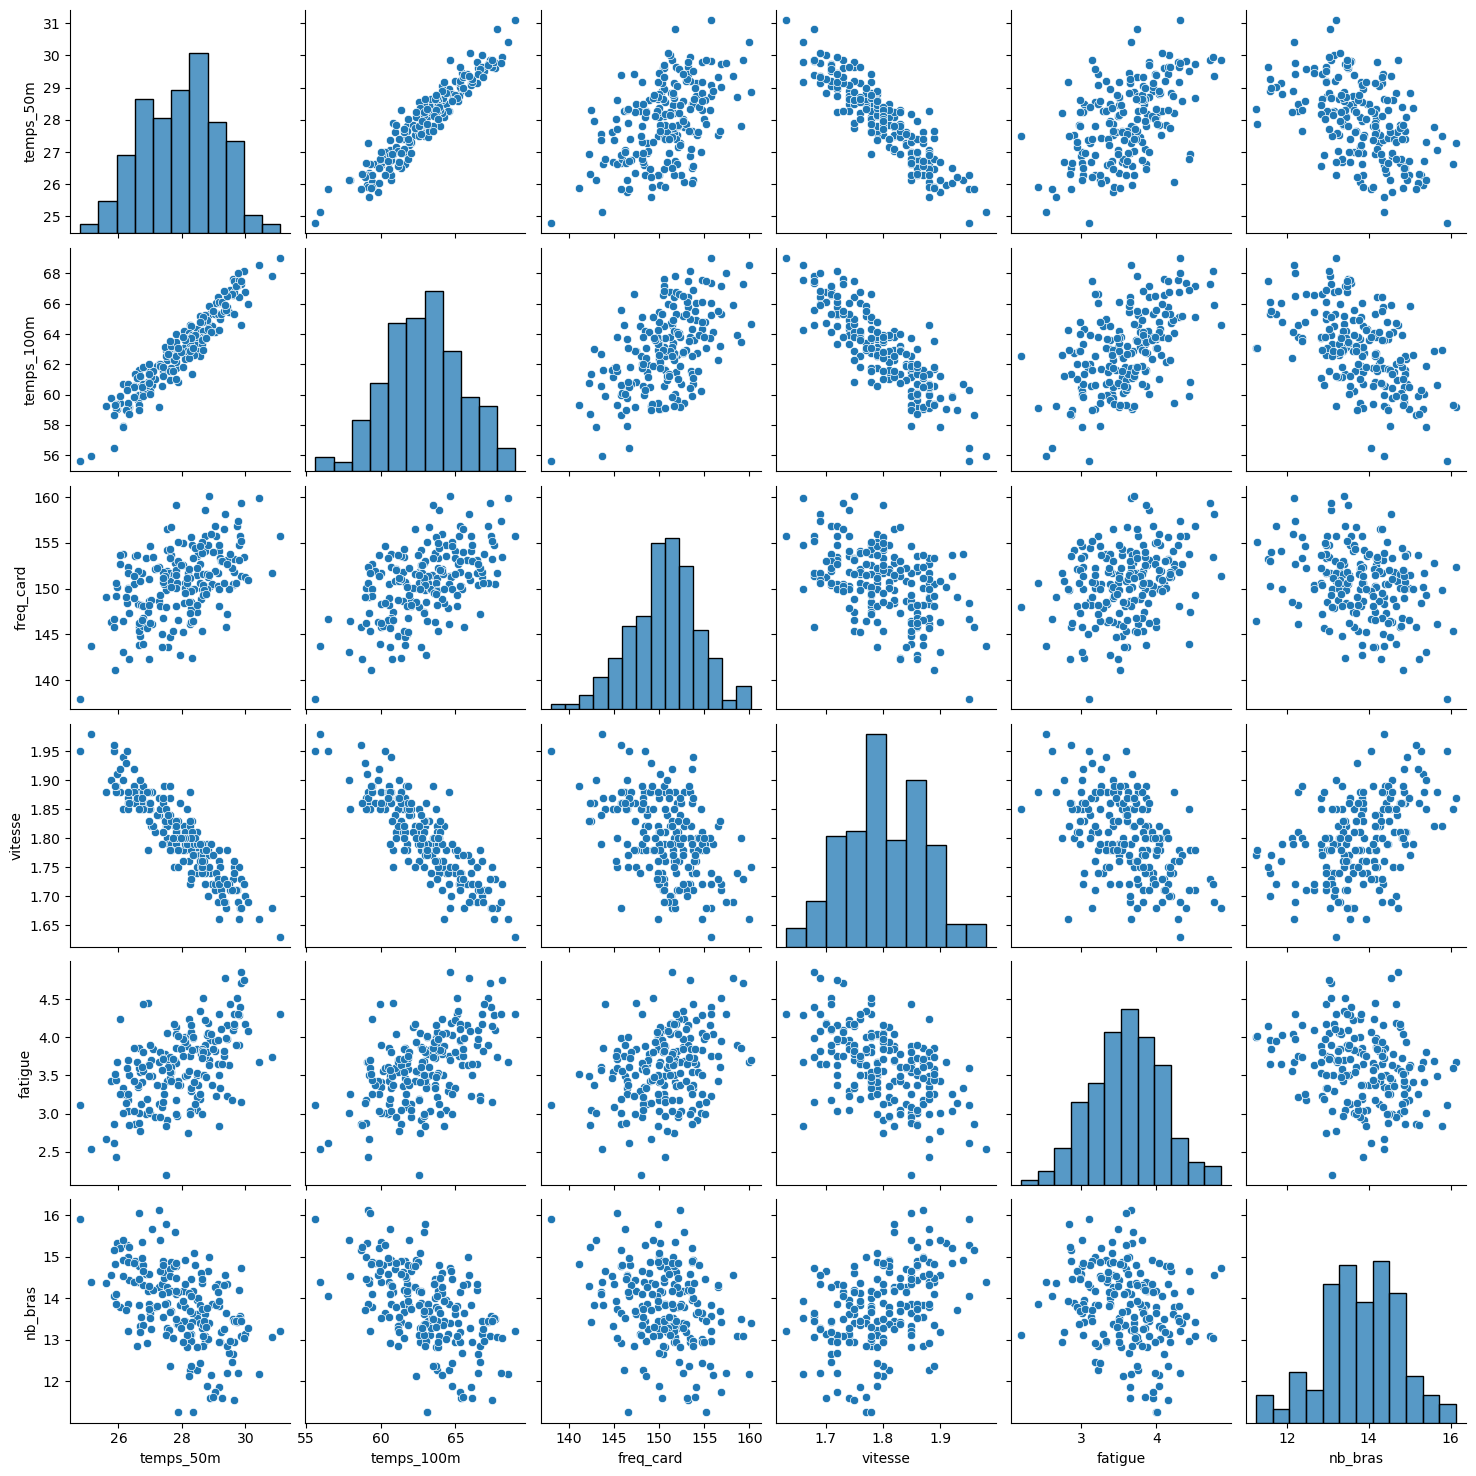

In [3]:
sns.pairplot(data)

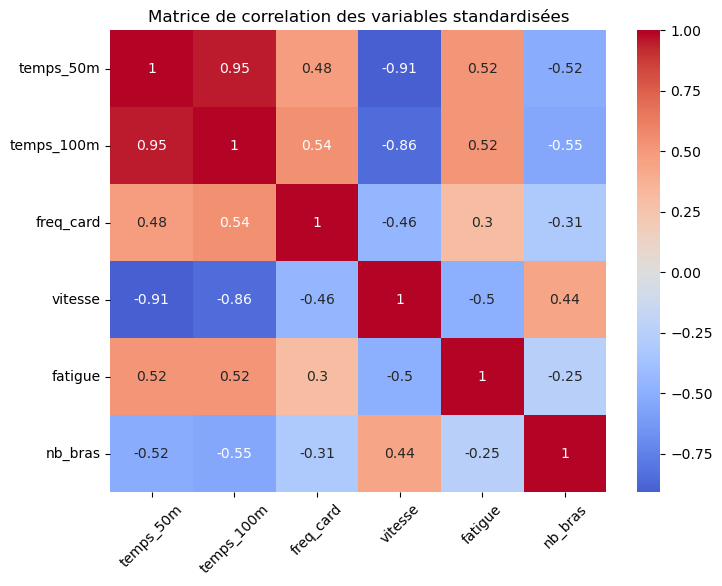

<Figure size 640x480 with 0 Axes>

In [4]:
# Standardisation des données
scaler = StandardScaler()
X_std = scaler.fit_transform(data)

X_corr = np.corrcoef(X_std.T)

# visualisation de la matrice de correlation
plt.figure(figsize=(8, 6))
sns.heatmap(X_corr, annot=True, cmap="coolwarm", center=0, xticklabels=data.columns, yticklabels=data.columns)
plt.title("Matrice de correlation des variables standardisées")
plt.xticks(rotation=45)
plt.show()
plt.clf()

## 3.1 Methode PCA par fonction

Composante 1 : 63.74% de variance expliquée
Composante 2 : 12.56% de variance expliquée
Composante 3 : 11.42% de variance expliquée
Composante 4 : 9.38% de variance expliquée
Composante 5 : 2.29% de variance expliquée
Composante 6 : 0.61% de variance expliquée
Variance totale expliquée : 100.00%
Nombre de composantes suggérées : 2
Clusters des nageurs :


,PC1,PC2,cluster
1,0.364395,0.223811,1
2,0.703066,-0.766598,1
3,-2.779616,1.077689,2
4,2.197396,-0.986762,0
5,-1.221689,-0.070992,2
...,...,...,...
196,0.579778,-0.453931,1
197,1.632464,-1.399049,0
198,2.359034,0.071941,0
199,-0.310636,0.594851,1


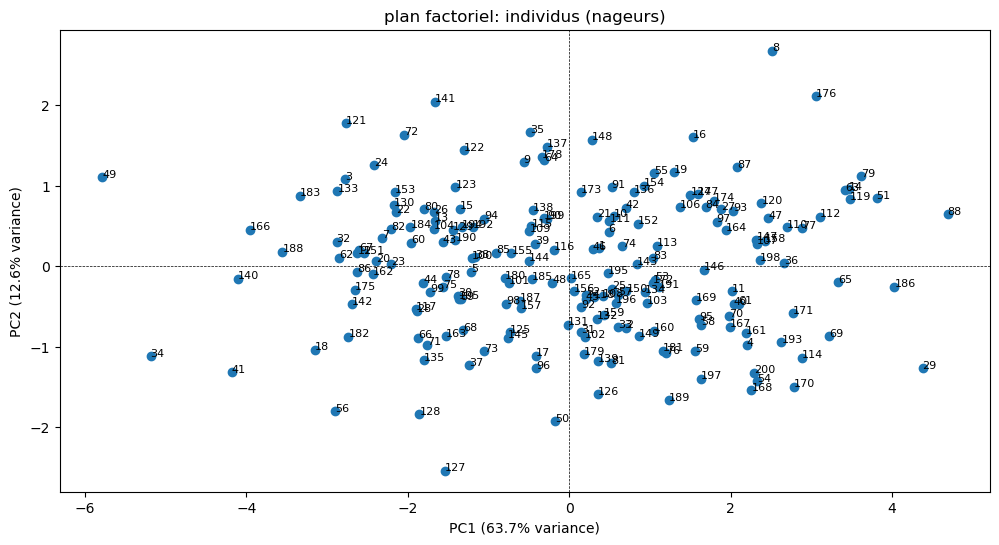

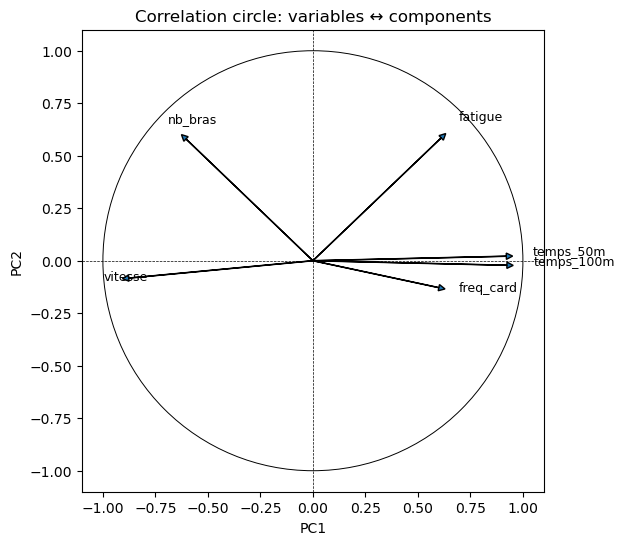

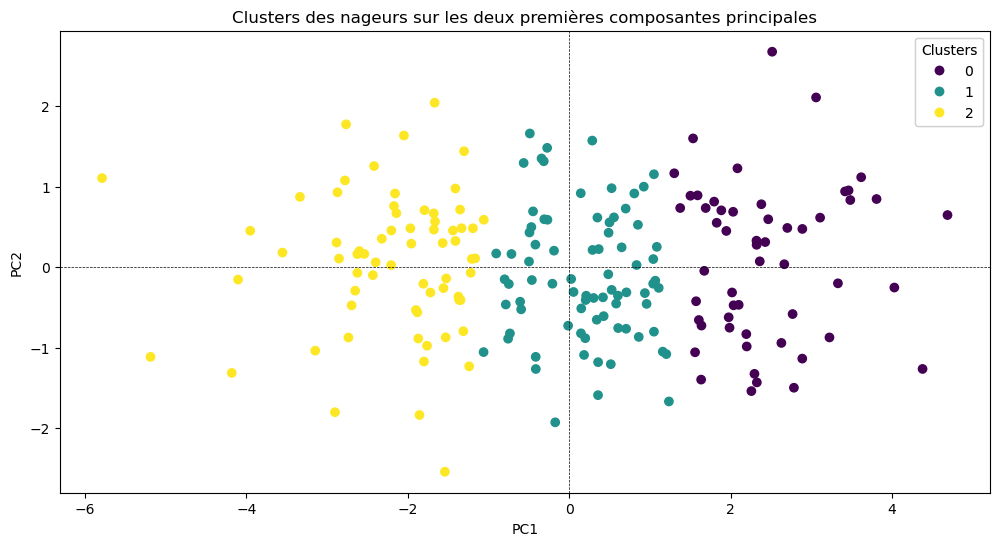

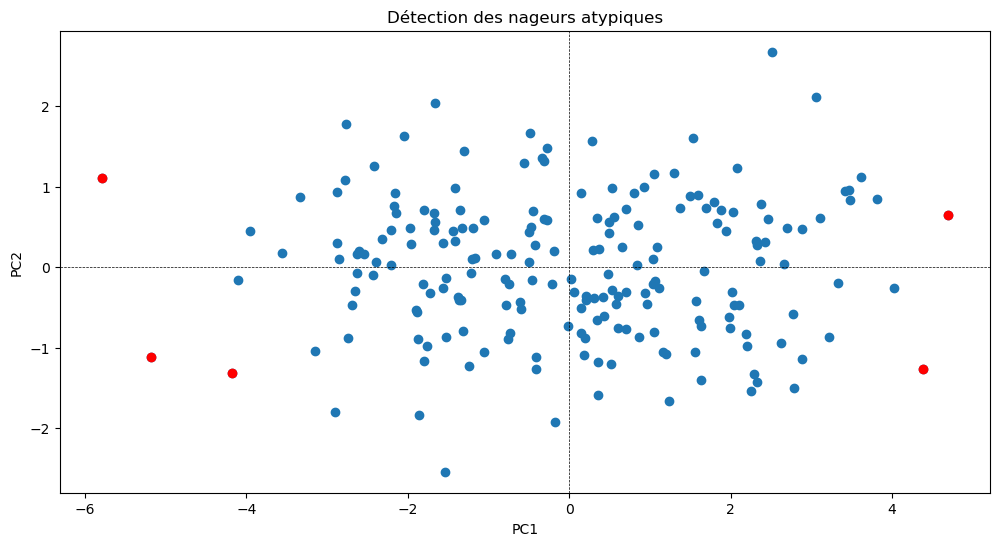

(array([0.63737535, 0.1256427 , 0.11423085, 0.09375385, 0.02288551,
        0.00611175]),
 np.float64(1.0),
 2,
           PC1       PC2  cluster  distance
 1    0.364395  0.223811        1  0.427639
 2    0.703066 -0.766598        1  1.040180
 3   -2.779616  1.077689        2  2.981221
 4    2.197396 -0.986762        0  2.408786
 5   -1.221689 -0.070992        2  1.223750
 ..        ...       ...      ...       ...
 196  0.579778 -0.453931        1  0.736339
 197  1.632464 -1.399049        0  2.149948
 198  2.359034  0.071941        0  2.360131
 199 -0.310636  0.594851        1  0.671076
 200  2.293401 -1.327327        0  2.649809
 
 [200 rows x 4 columns])

In [5]:
from scripts.pca_analysis import perform_pca

perform_pca(data)

## 3.2 Methode PCA par entrees successives

In [6]:
# Compute correlations between variables and components (correlation circle)
# Assurez-vous que les scores sont définis à l'aide de la transformation PCA
pca = PCA(n_components=2)
scores = pca.fit_transform(X_std)

# Affichage des vecteurs propres de la matrice covariante pour les 2 composantes principales
print("\nVecteurs propres (loadings) pour les 2 composantes principales :\n")

df_pca = pd.DataFrame((pca.components_.T).round(2), columns=["PC1", "PC2"], index=data.columns)
display(df_pca)


# Affiche les 5 premiers scores pour vérifier
# Nous calculons la corrélation entre chaque variable standardisée et chaque composante (scores)
print("\nCorrelation entre variables standardisées et composantes (scores) :")
corr_var_comp = np.corrcoef(X_std.T, scores.T)[:X_std.shape[1], X_std.shape[1]:]

corr_df = pd.DataFrame((corr_var_comp).round(2), index=data.columns, columns=["PC1", "PC2"])
display(corr_df)


Vecteurs propres (loadings) pour les 2 composantes principales :



,PC1,PC2
temps_50m,0.49,0.03
temps_100m,0.49,-0.03
freq_card,0.32,-0.15
vitesse,-0.46,-0.10
fatigue,0.32,0.70
nb_bras,-0.32,0.69



Correlation entre variables standardisées et composantes (scores) :


,PC1,PC2
temps_50m,0.95,0.02
temps_100m,0.95,-0.02
freq_card,0.63,-0.13
vitesse,-0.91,-0.09
fatigue,0.63,0.61
nb_bras,-0.63,0.60


In [7]:
# Component (loadings) table as returned by sklearn (components as eigenvectors)
loadings = pd.DataFrame(pca.components_.T, index=data.columns, columns=["PC1_raw", "PC2_raw"])

# Display results
display("vecteurs propres pour chaque composante", loadings.round(2))
display("Correlation entre variables et composantes (cercle de corrélation)", corr_df.round(2))

'vecteurs propres pour chaque composante'

,PC1_raw,PC2_raw
temps_50m,0.49,0.03
temps_100m,0.49,-0.03
freq_card,0.32,-0.15
vitesse,-0.46,-0.10
fatigue,0.32,0.70
nb_bras,-0.32,0.69


'Correlation entre variables et composantes (cercle de corrélation)'

,PC1,PC2
temps_50m,0.95,0.02
temps_100m,0.95,-0.02
freq_card,0.63,-0.13
vitesse,-0.91,-0.09
fatigue,0.63,0.61
nb_bras,-0.63,0.60


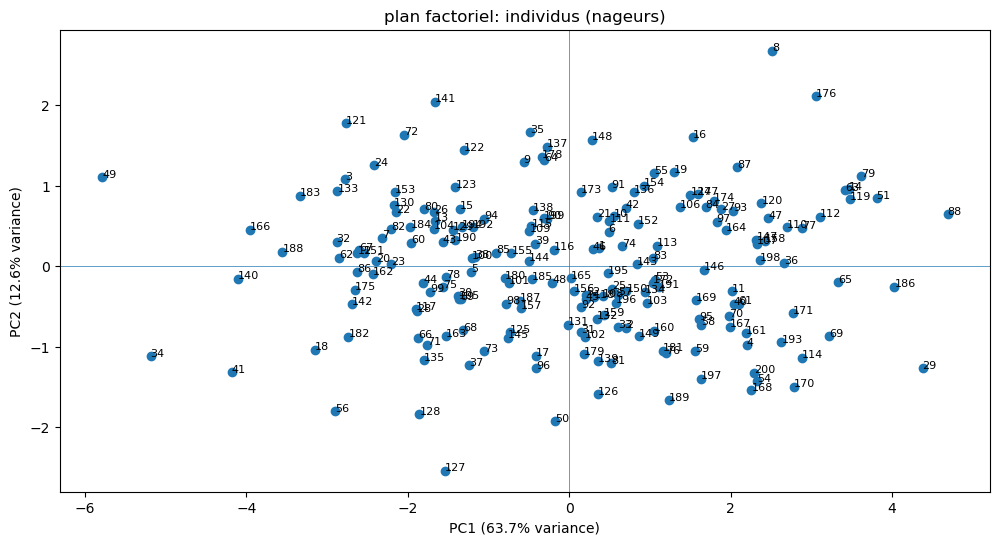

In [8]:
# Plot 1: individuals on the PC1 x PC2 plane
fig1, ax1 = plt.subplots(figsize=(12,6))
ax1.scatter(scores[:,0], scores[:,1])
for i, txt in enumerate(range(1, n+1)):
    ax1.annotate(str(txt), (scores[i,0], scores[i,1]), fontsize=8)
ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax1.set_title("plan factoriel: individus (nageurs)")
ax1.axhline(0, linewidth=0.5)
ax1.axvline(0, linewidth=0.5)
plt.show()

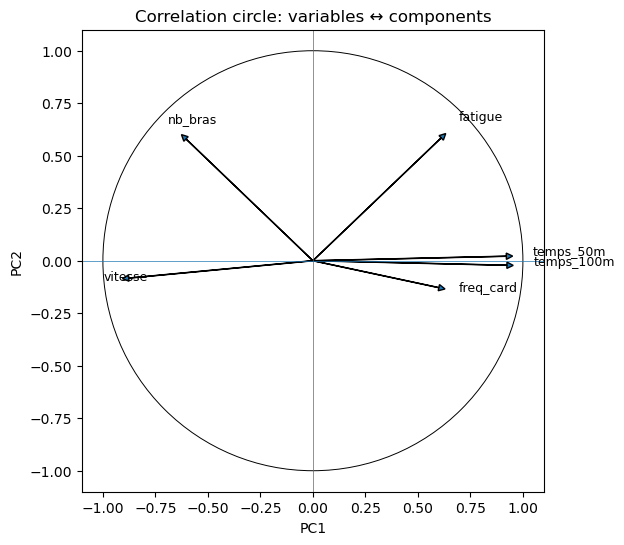

In [9]:
# Plot 2: correlation circle
fig2, ax2 = plt.subplots(figsize=(6,6))
# unit circle
circle = plt.Circle((0,0), 1, color='black', fill=False, linewidth=0.7)
ax2.add_artist(circle)
# arrows for each variable
for i, var in enumerate(data.columns):
    x = corr_var_comp[i,0]
    y = corr_var_comp[i,1]
    ax2.arrow(0, 0, x, y, head_width=0.03, head_length=0.03, length_includes_head=True)
    ax2.text(x*1.1, y*1.1, var, fontsize=9)
ax2.set_xlim(-1.1, 1.1)
ax2.set_ylim(-1.1, 1.1)
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_title("Correlation circle: variables ↔ components")
ax2.axhline(0, linewidth=0.5)
ax2.axvline(0, linewidth=0.5)
ax2.set_aspect('equal', 'box')
plt.show()

In [10]:
# Display individual scores (projections)
scores_df = pd.DataFrame(scores, columns=["PC1_score", "PC2_score"])
scores_df.index = [f"Swimmer_{i}" for i in range(1, n+1)]
display("Individuals' scores (projections on PC1/PC2)", scores_df.round(4))

"Individuals' scores (projections on PC1/PC2)"

,PC1_score,PC2_score
Swimmer_1,0.3644,0.2238
Swimmer_2,0.7031,-0.7666
Swimmer_3,-2.7796,1.0777
Swimmer_4,2.1974,-0.9868
Swimmer_5,-1.2217,-0.0710
...,...,...
Swimmer_196,0.5798,-0.4539
Swimmer_197,1.6325,-1.3990
Swimmer_198,2.3590,0.0719
Swimmer_199,-0.3106,0.5949


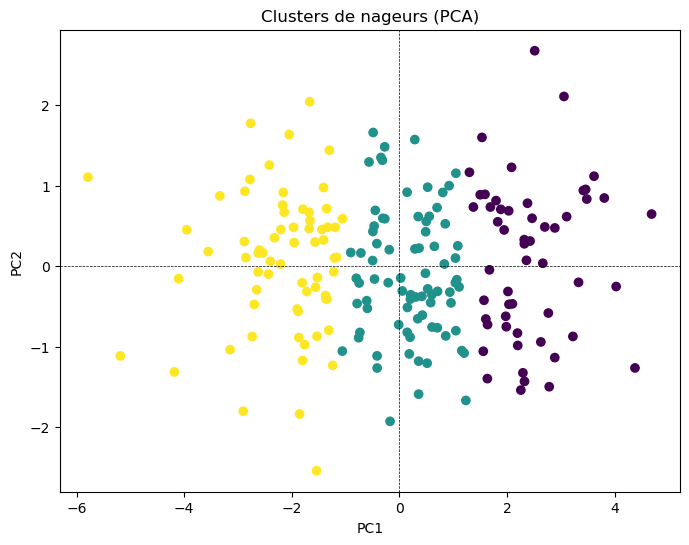

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=3, random_state=0)
clusters = kmeans.fit_predict(scores_df[['PC1_score','PC2_score']])

scores_df['cluster'] = clusters

plt.figure(figsize=(8,6))
plt.scatter(scores_df['PC1_score'], scores_df['PC2_score'], c=scores_df['cluster'], cmap='viridis')
plt.axhline(0, linewidth=0.5, color='black', linestyle='--')
plt.axvline(0, linewidth=0.5, color='black', linestyle='--')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters de nageurs (PCA)")
plt.show()

            PC1_score  PC2_score  cluster  distance
Swimmer_49  -5.789046   1.106538        2  5.893851
Swimmer_34  -5.188600  -1.116711        2  5.307412
Swimmer_88   4.684808   0.647203        0  4.729302
Swimmer_29   4.375766  -1.266457        0  4.555353
Swimmer_41  -4.182431  -1.315839        2  4.384537


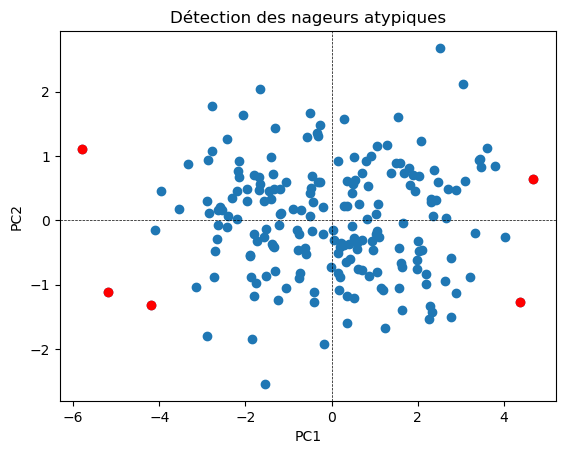

In [12]:
scores_df['distance'] = np.sqrt(scores_df['PC1_score']**2 + scores_df['PC2_score']**2)
outliers = scores_df.sort_values('distance', ascending=False).head(5)

#affichage des nageurs atypiques
print(outliers)
plt.scatter(scores_df['PC1_score'], scores_df['PC2_score'])
plt.scatter(outliers['PC1_score'], outliers['PC2_score'], color='red')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.axhline(0, linewidth=0.5, color='black', linestyle='--')
plt.axvline(0, linewidth=0.5, color='black', linestyle='--')
plt.title("Détection des nageurs atypiques")
plt.show()